In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

ndevices = 32
import os
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={ndevices}"
os.environ["OMP_NUM_THREADS"] = f"{ndevices}"
os.environ["MKL_NUM_THREADS"] = f"{ndevices}"
os.environ["NUMEXPR_NUM_THREADS"] = f"{ndevices}"
os.environ["OPENBLAS_NUM_THREADS"] = f"{ndevices}"
os.environ["VECLIB_MAXIMUM_THREADS"] = f"{ndevices}"
os.environ["NUMBA_NUM_THREADS"] = f"{ndevices}"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"

from tqdm import tqdm
import multiprocessing
import pandas as pd
import sys
import glob
from functools import partial
from astropy.io import fits, ascii
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table
from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value, wCDM, LambdaCDM
import scipy.stats as st
from scipy.optimize import minimize
from scipy.signal import fftconvolve
import warnings
import h5py
import emcee
import corner
from scipy import stats
from scipy.interpolate import interp1d

import time
plt.style.use('style.mplstyle')

In [2]:
bands = ['u', 'g', 'r', 'i', 'z']#, 'y']
bands_idx = {b: i for i, b in enumerate(bands)}

def populate_sdss_fields(d, fits_data, fits_data_2):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(f"Warning: {d['sdss_name']} not found in SDSS data")
        return d
    i = i[0]
    if np.any(fits_data_2['PSFFLUX'][i,:] <= 0):
        return d
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        d['apparent_mag_z'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,4]) + 22.5
        d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
        d['apparent_mag_r'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,2]) + 22.5
        d['apparent_mag_g'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,1]) + 22.5
        d['apparent_mag_u'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,0]) + 22.5
        d['apparent_mag_z_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,4])/fits_data_2['PSFFLUX'][i,4]
        d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
        d['apparent_mag_r_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,2])/fits_data_2['PSFFLUX'][i,2]
        d['apparent_mag_g_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,1])/fits_data_2['PSFFLUX'][i,1]
        d['apparent_mag_u_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,0])/fits_data_2['PSFFLUX'][i,0]
        d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
    if any(issubclass(warning.category, RuntimeWarning) for warning in w):
        print(f"RuntimeWarning occurred for {d['sdss_name']}")
        print(fits_data_2['PSFFLUX'][i,:])
        print(w)
    return d


def read_quasars_from_hdf5(file_path):
    quasar_list = []

    hdul = fits.open('data/dr16q_prop_May01_2024.fits')
    fits_data = hdul[1].data  # Assuming the data is in the first extension    
    fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    


    with h5py.File(file_path, "r") as hdf:
        for group_name in tqdm(hdf.keys(), desc="Reading quasars from HDF5"):
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            populate_sdss_fields(quasar, fits_data, fits_data_2)
            quasar_list.append(quasar)
    return quasar_list

In [3]:
hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

#quasar_list = read_quasars_from_hdf5("data/may13_objs_tauwavelength_taublr_freebreak_newpriors_all_merged.h5")
quasar_list = read_quasars_from_hdf5("data/may15_objs_tauwavelength_taublr_etasep_newpriors1_all_merged.h5")

df = pd.DataFrame(quasar_list)
#quasar_list = [populate_sdss_fields(q, fits_data, fits_data_2) for q in quasar_list]

Reading quasars from HDF5: 100%|██████████| 3988/3988 [00:18<00:00, 217.91it/s]


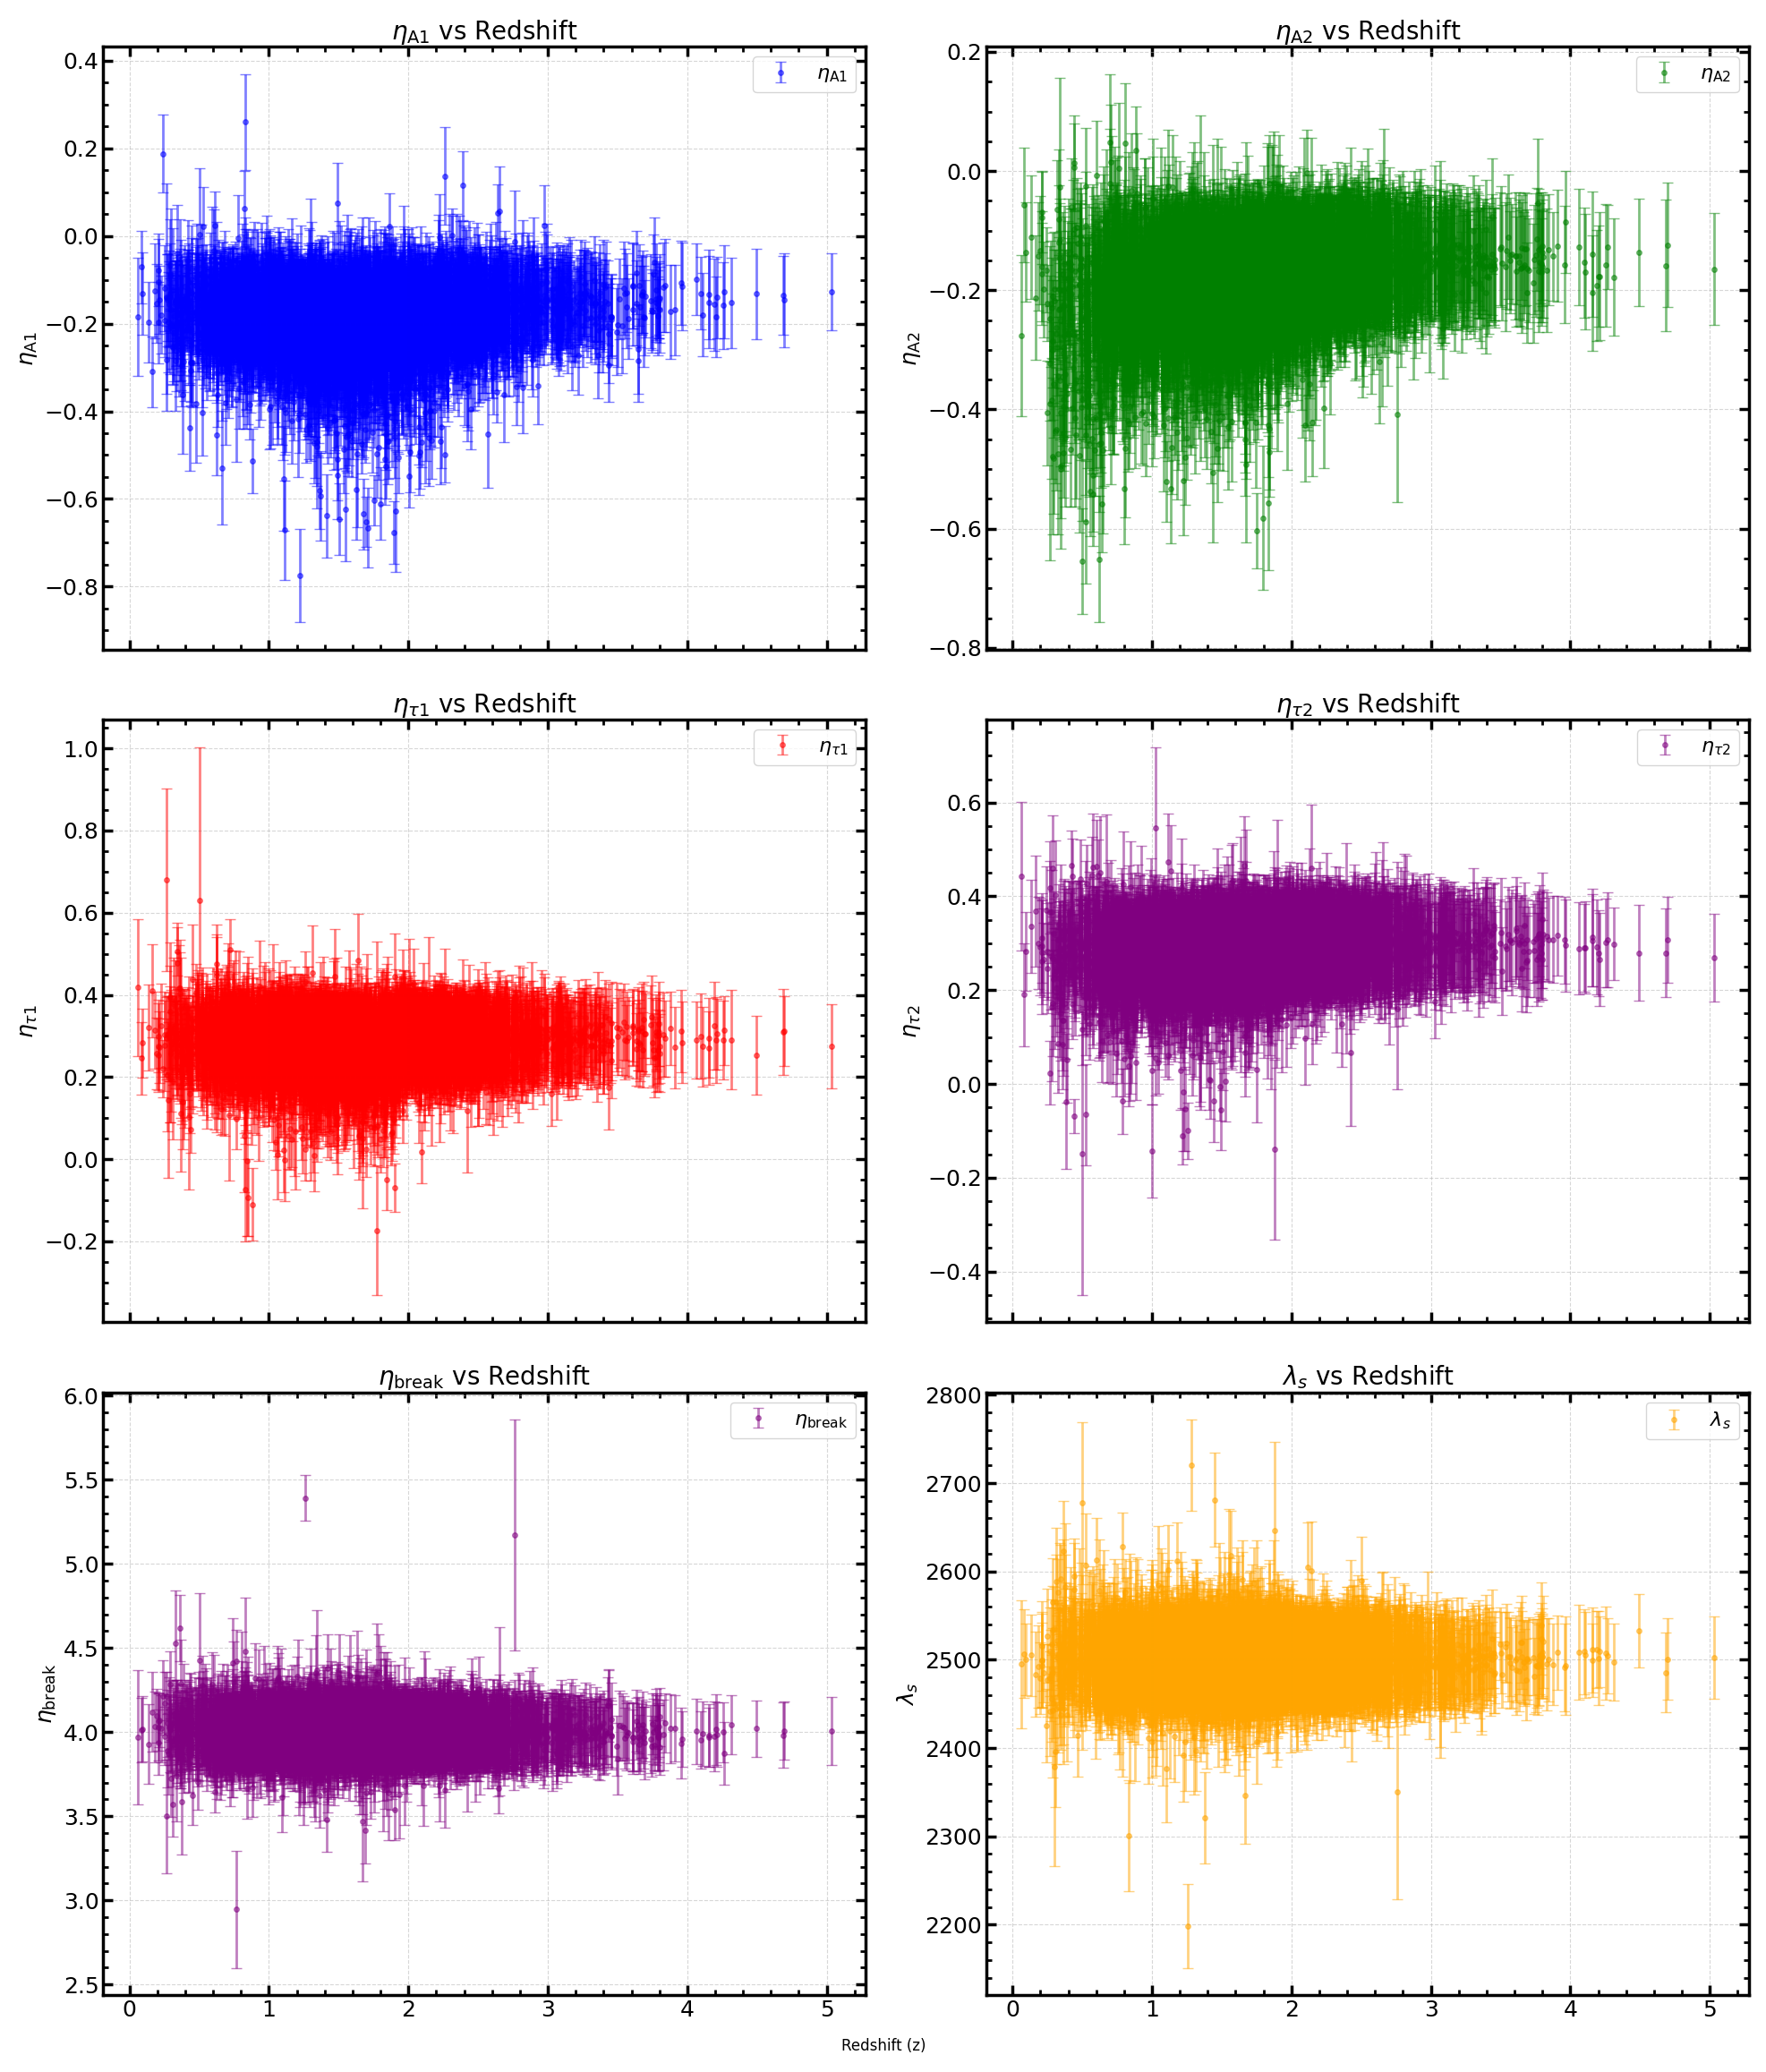

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(10*2, 8*3), sharex=True)
axes = axes.flatten()
d = df

# Define the parameters for each plot
plot_params = [
    {'y': 'eta_A1', 'label': r'$\eta_\mathrm{A1}$', 'color': 'blue'},
    {'y': 'eta_A2', 'label': r'$\eta_\mathrm{A2}$', 'color': 'green'},
    {'y': 'eta_tau1', 'label': r'$\eta_{\tau1}$', 'color': 'red'},
    {'y': 'eta_tau2', 'label': r'$\eta_{\tau2}$', 'color': 'purple'},
    {'y': 'eta_break', 'label': r'$\eta_\mathrm{break}$', 'color': 'purple'},
    {'y': 'lam_s', 'label': r'$\lambda_s$', 'color': 'orange'}
]

# Loop through each parameter and create the corresponding plot
for i, params in enumerate(plot_params):
    y_err = d[f"{params['y']}_err"] if f"{params['y']}_err" in d.columns else None
    axes[i].errorbar(d['z'], d[params['y']], yerr=y_err, fmt='o', alpha=0.5, markersize=4, label=params['label'], color=params['color'])
    #axes[i].scatter(d['z'], d[params['y']], alpha=0.7, s=10, label=params['label'], color=params['color'])
    axes[i].set_ylabel(params['label'])
    axes[i].set_title(f"{params['label']} vs Redshift")
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend()

#fig.suptitle("removed_ebv", fontsize=28, y=0.99)
# Adjust layout and add shared x-axis label
fig.text(0.5, 0.04, 'Redshift (z)', ha='center', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])
#plt.savefig("plots/etas.pdf", format="pdf")
plt.show()

In [7]:
from hubble_fit import *
df_pantheon = pd.read_csv('https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true',
                        sep=r'\s+')
df_agn = df[df['ebv'] < 0.05]
df_agn = df_agn[df_agn['log_tau_UV_RF'].between(2, 3.5)]
df_agn = df_agn[df_agn['log_sigma_UV'] < -0.4]
df_agn = df_agn[df_agn['eta_tau1'].between(0.25, 0.35)]
df_agn = df_agn[df_agn['eta_tau2'].between(0.2, 0.35)]
df_agn = df_agn[df_agn['eta_A1'].between(-0.23, -0.1)]
df_agn = df_agn[df_agn['eta_A2'].between(-0.4, -0.1)]
df_agn = df_agn[df_agn['eta_break'].between(3.9, 4.1)]
df_agn = df_agn[df_agn['lam_s'].between(2450, 2550)]
df_agn['color'] = df_agn['apparent_mag_i'] - df_agn['apparent_mag_r']
df_agn = df_agn[df_agn['color'].between(-1, 1)]

for k in ['log_tau_UV_RF_err', 'log_sigma_UV_err', 'eta_A1_err', 'eta_A2_err', 'eta_tau1_err', 'eta_tau2_err']:
    df_agn = df_agn[df_agn[k] < 0.4]
df_agn = df_agn.reset_index(drop=True)

cosmo_model = 'Flatw0waCDM'
sampler, _ = run_mcmc_pipeline(df_agn, df_pantheon, only_sna=False, cosmo_model=cosmo_model)


100%|██████████| 50/50 [00:12<00:00,  4.09it/s]


<string>:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


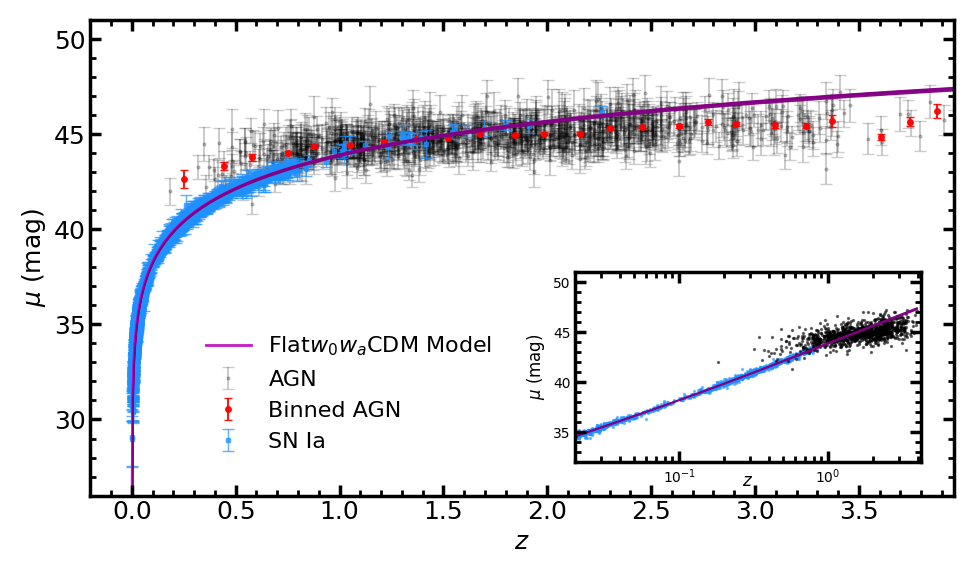

In [10]:
residuals, mu_pred_std = plot_hubble(sampler, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True)

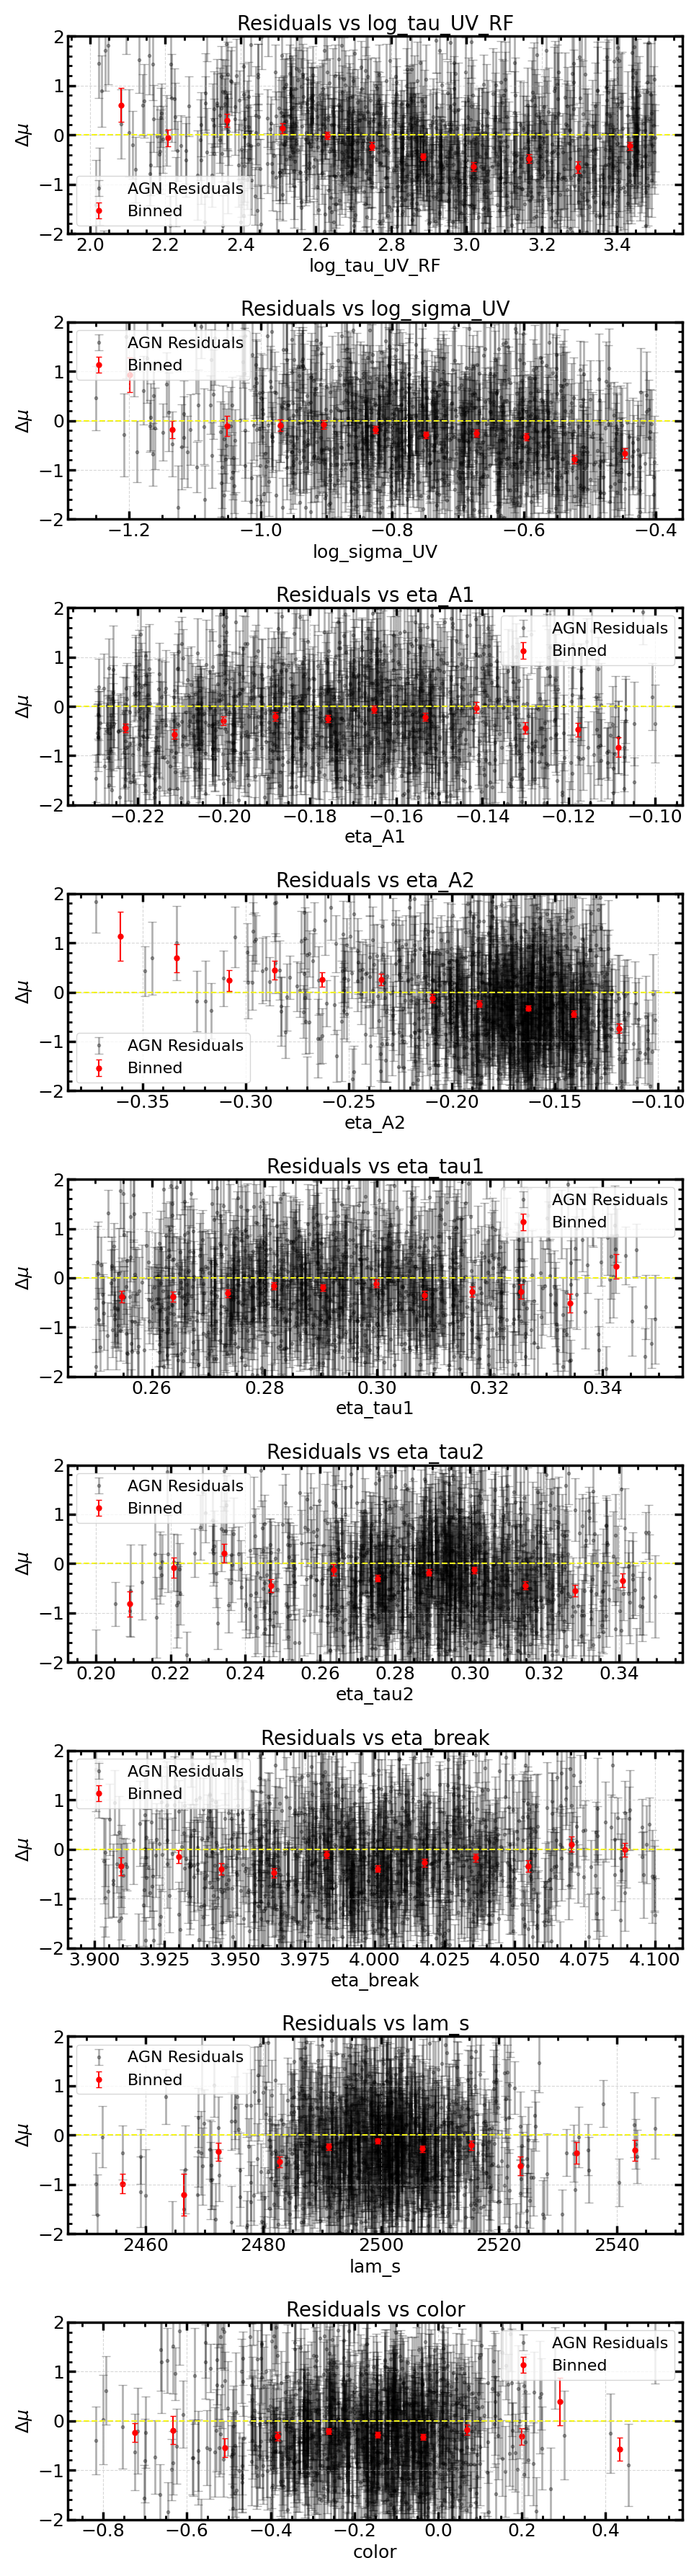

In [ ]:
def plot_residuals(residual_key, ax2):
    # --- Residuals vs E(B–V) binning ---
    ebv_bins = np.linspace(df_agn[residual_key].min(), df_agn[residual_key].max(), 12)
    ebv_bin_idx = np.digitize(df_agn[residual_key], ebv_bins)
    binned_ebv = [np.median(df_agn[residual_key][ebv_bin_idx == i]) for i in range(1, len(ebv_bins))]
    binned_resid = [np.median(residuals[ebv_bin_idx == i]) for i in range(1, len(ebv_bins))]
    binned_resid_err = [np.std(residuals[ebv_bin_idx == i]) / np.sqrt(np.sum(ebv_bin_idx == i)) for i in range(1, len(ebv_bins))]
    # Residuals panel
    ax2.errorbar(df_agn[residual_key], residuals, yerr=mu_pred_std, fmt='o', color='k', alpha=0.3, markersize=3, label='AGN Residuals', zorder=-3)
    ax2.axhline(0, color="yellow", lw=1.5, linestyle="--", zorder=-2)
    ax2.errorbar(binned_ebv, binned_resid, yerr=binned_resid_err, fmt='o', color='red', lw=1.5, markersize=5, capsize=3, label='Binned', zorder=-1)
    ax2.set_xlabel(residual_key)
    ax2.set_ylabel(r"$\Delta \mu$")

residual_key_list = ['log_tau_UV_RF', 'log_sigma_UV', 'eta_A1', 'eta_A2', 'eta_tau1', 'eta_tau2', 'eta_break', 'lam_s', 'color']
nrows = len(residual_key_list)

fig, axs = plt.subplots(nrows, 1, figsize=(10, nrows*4), sharey=False)
axs = axs.flatten()
for i, residual_key in enumerate(residual_key_list):
    plot_residuals(residual_key, axs[i])
    axs[i].set_title(f"Residuals vs {residual_key}")
    axs[i].grid(True, linestyle='--', alpha=0.5)
    axs[i].legend()
    axs[i].set_ylim(-2, 2)
    #axs[i].set_xlim(-0.1, 0.5)
fig.tight_layout()